In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, skew, kurtosis

# Konfigurasi tampilan
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10
})
pd.set_option("display.float_format", "{:.4f}".format)

In [2]:
df = pd.read_csv("Gaming_Academic_Performance.csv")

print(f"Dataset awal  : {df.shape[0]} baris x {df.shape[1]} kolom")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"Duplikasi     : {df.duplicated().sum()}")

df = df.dropna().drop_duplicates().reset_index(drop=True)
print(f"\n Dataset akhir: {df.shape[0]} baris x {df.shape[1]} kolom")

df.head()

Dataset awal  : 8000 baris x 14 kolom
Missing values: 0
Duplikasi     : 0

 Dataset akhir: 8000 baris x 14 kolom


,student_id,age,gender,gaming_hours,study_hours,sleep_hours,attendance,gaming_genre,social_activity,device_usage,reaction_time_ms,addiction_score,stress_level,grades
0,1,22,Male,7.2300,8.7800,6.9600,91.4400,FPS,3.2500,9.3600,235.8400,14.6900,Low,86.4596
1,2,19,Male,0.0700,8.7200,7.6300,63.6300,Casual,1.0200,3.2100,328.7100,2.4700,Medium,98.2300
2,3,23,Female,1.7300,9.5600,4.4000,83.2600,Casual,3.4600,5.5600,313.6100,4.7300,High,90.5600
3,4,20,Female,6.6200,1.6800,7.8300,75.0400,RPG,1.4600,11.7800,241.8400,14.5400,Low,32.6700
4,5,22,Female,5.3600,5.8300,5.5500,65.5700,FPS,1.0100,8.2300,249.3100,12.4800,Low,58.7100


In [3]:
def kategori_gaming(jam):
    if jam < 2:
        return "Rendah (<2 jam)"
    elif jam < 5:
        return "Sedang (2-5 jam)"
    else:
        return "Tinggi (>=5 jam)"

df["gaming_category"] = df["gaming_hours"].apply(kategori_gaming)

print("Distribusi Kategori Gaming:")
print(df["gaming_category"].value_counts().to_string())

Distribusi Kategori Gaming:
gaming_category
Tinggi (>=5 jam)    3140
Sedang (2-5 jam)    2965
Rendah (<2 jam)     1895


In [5]:
desc = df[["gaming_hours"]].describe().T
desc.columns = ["N", "Mean", "Std Dev", "Min", "Q1", "Median (Q2)", "Q3", "Max"]
desc.index = ["Gaming Hours (jam/hari)"]
desc

,N,Mean,Std Dev,Min,Q1,Median (Q2),Q3,Max
Gaming Hours (jam/hari),8000.0000,4.0858,2.3088,0.0000,2.1300,4.1300,6.0600,8.0000


In [5]:
gaming = df["gaming_hours"]
grades = df["grades"]

tendensi = pd.DataFrame({
    "Mean"  : [gaming.mean(),  grades.mean()],
    "Median": [gaming.median(), grades.median()],
    "Modus" : [gaming.mode()[0], grades.mode()[0]]
}, index=["Gaming Hours (jam/hari)", "Grades (nilai)"])

tendensi

,Mean,Median,Modus
Gaming Hours (jam/hari),4.0858,4.1300,6.2300
Grades (nilai),66.1808,67.0700,100.0000


In [6]:
variabilitas = pd.DataFrame({
    "Varians"        : [gaming.var(),  grades.var()],
    "Standar Deviasi": [gaming.std(),  grades.std()],
    "Range"          : [gaming.max() - gaming.min(), grades.max() - grades.min()],
    "IQR"            : [gaming.quantile(0.75) - gaming.quantile(0.25),
                        grades.quantile(0.75) - grades.quantile(0.25)]
}, index=["Gaming Hours (jam/hari)", "Grades (nilai)"])

variabilitas

,Varians,Standar Deviasi,Range,IQR
Gaming Hours (jam/hari),5.3306,2.3088,8.0000,3.9300
Grades (nilai),502.7472,22.4220,118.6329,34.1124


In [7]:
corr, p_value = pearsonr(gaming, grades)

print("=" * 45)
print("         HASIL UJI KORELASI PEARSON")
print("=" * 45)
print(f"  Nilai Korelasi (r) : {corr:.4f}")
print(f"  P-Value            : {p_value:.4e}")
print(f"  Signifikansi (a)   : 0.05")
print("-" * 45)

arah = "negatif" if corr < 0 else "positif"
if abs(corr) < 0.2:
    kekuatan = "sangat lemah"
elif abs(corr) < 0.4:
    kekuatan = "lemah"
elif abs(corr) < 0.6:
    kekuatan = "sedang"
elif abs(corr) < 0.8:
    kekuatan = "kuat"
else:
    kekuatan = "sangat kuat"

signifikan = "SIGNIFIKAN" if p_value < 0.05 else "TIDAK SIGNIFIKAN"
op = "<" if p_value < 0.05 else ">="
print(f"  Kekuatan korelasi  : {kekuatan} ({arah})")
print(f"  Kesimpulan         : Hubungan {signifikan} (p {op} 0.05)")
print("=" * 45)

         HASIL UJI KORELASI PEARSON
  Nilai Korelasi (r) : -0.5513
  P-Value            : 0.0000e+00
  Signifikansi (a)   : 0.05
---------------------------------------------
  Kekuatan korelasi  : sedang (negatif)
  Kesimpulan         : Hubungan SIGNIFIKAN (p < 0.05)


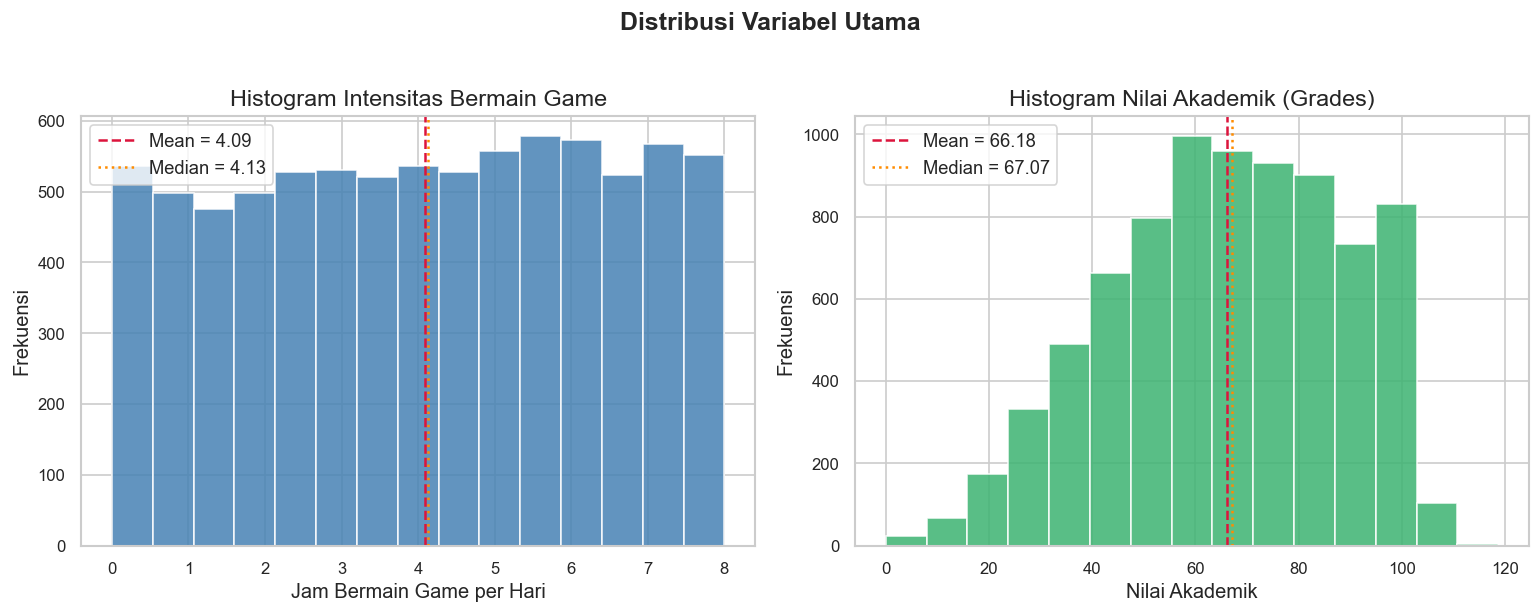

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histogram Gaming Hours
axes[0].hist(gaming, bins=15, color="steelblue", edgecolor="white", alpha=0.85)
axes[0].axvline(gaming.mean(),   color="crimson",   linestyle="--", linewidth=1.5, label=f"Mean = {gaming.mean():.2f}")
axes[0].axvline(gaming.median(), color="darkorange", linestyle=":",  linewidth=1.5, label=f"Median = {gaming.median():.2f}")
axes[0].set_title("Histogram Intensitas Bermain Game")
axes[0].set_xlabel("Jam Bermain Game per Hari")
axes[0].set_ylabel("Frekuensi")
axes[0].legend()

# Histogram Grades
axes[1].hist(grades, bins=15, color="mediumseagreen", edgecolor="white", alpha=0.85)
axes[1].axvline(grades.mean(),   color="crimson",   linestyle="--", linewidth=1.5, label=f"Mean = {grades.mean():.2f}")
axes[1].axvline(grades.median(), color="darkorange", linestyle=":",  linewidth=1.5, label=f"Median = {grades.median():.2f}")
axes[1].set_title("Histogram Nilai Akademik (Grades)")
axes[1].set_xlabel("Nilai Akademik")
axes[1].set_ylabel("Frekuensi")
axes[1].legend()

plt.suptitle("Distribusi Variabel Utama", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

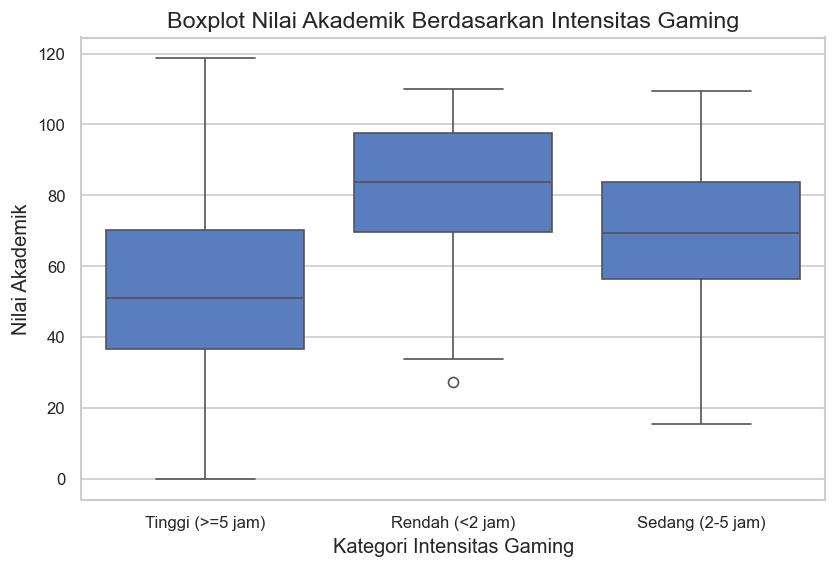

In [9]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='gaming_category',
    y='grades',
    data=df
)

plt.title('Boxplot Nilai Akademik Berdasarkan Intensitas Gaming')
plt.xlabel('Kategori Intensitas Gaming')
plt.ylabel('Nilai Akademik')

plt.show()

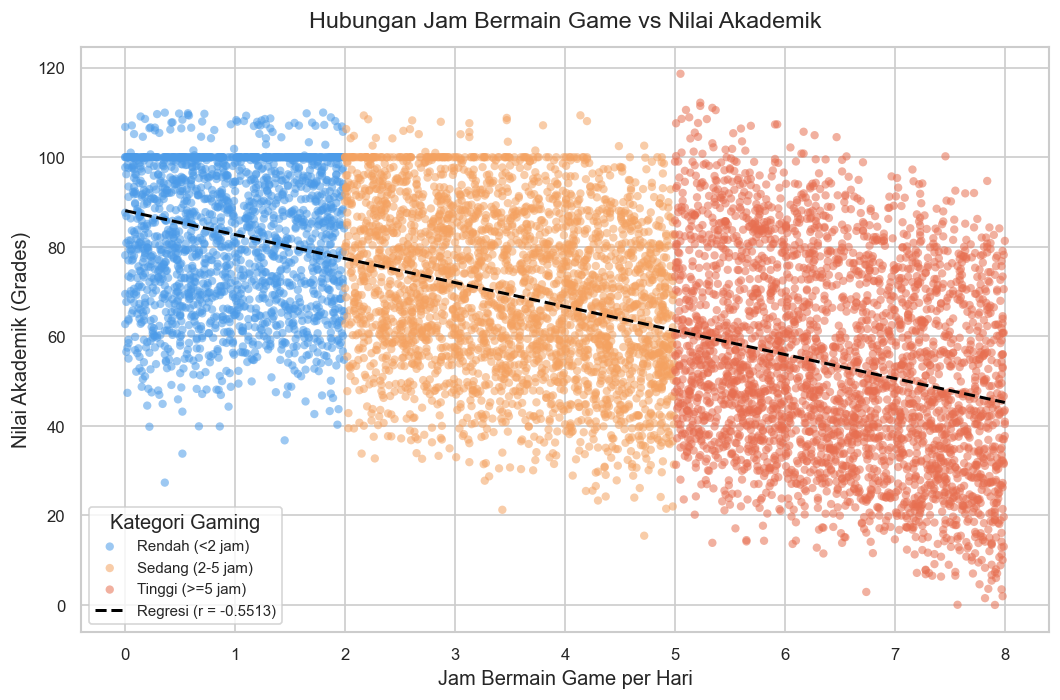

In [10]:
fig, ax = plt.subplots(figsize=(9, 6))

scatter_colors = {
    "Rendah (<2 jam)" : "#4C9BE8",
    "Sedang (2-5 jam)": "#F4A261",
    "Tinggi (>=5 jam)": "#E76F51"
}
for cat, color in scatter_colors.items():
    subset = df[df["gaming_category"] == cat]
    ax.scatter(subset["gaming_hours"], subset["grades"],
               label=cat, color=color, alpha=0.55, s=25, edgecolors="none")

# Garis regresi
m, b = np.polyfit(gaming, grades, 1)
x_line = np.linspace(gaming.min(), gaming.max(), 200)
ax.plot(x_line, m * x_line + b, color="black", linewidth=1.8,
        linestyle="--", label=f"Regresi (r = {corr:.4f})")

ax.set_title("Hubungan Jam Bermain Game vs Nilai Akademik", pad=12)
ax.set_xlabel("Jam Bermain Game per Hari")
ax.set_ylabel("Nilai Akademik (Grades)")
ax.legend(title="Kategori Gaming", fontsize=9)
plt.tight_layout()
plt.show()